# Dislay of time series data recorded on the Zeiss Cell Discoverer 7
_______________
This notebook is a method to plot ... \
The expected input is ... \
The generated output will be ...\
There are several input prompts along the way.

_______________

### *Disclaimer:* 
This notebook has been developed by Marie Held, image analyst in the Centre for Cell Imaging at The University of Liverpool. 
The source code can be found in: *INSERT GITHUB REPOSITORY LINK*

_______________

# How to use this notebook
## Structure of a notebook
The notebook contains two types of cell:

Text cells provide information and can be modified by douple-clicking the cell. You are currently reading the text cell. You can create a new text by double clicking on the contents of the cell.

Code cells contain code and the code can be modfied by selecting the cell. To execute the cell press [Shift + Enter] or click the Run button in the tools bar of the Notebook interface above. During exection, an asterisk will appear within the brackets.  After execution is done the asterisk will change into a number, i.e. the nth cell that has been executed during this session. The numbers indicate the order in which the cells have been executed which does not have to follow the order of the cells within the notebook. 

Any code output will be displayed below the cell.

## Before getting started
Before running this notebook, please ensure that you have the data to process accessible. Please note that you can currently **only use .csv files**. 

## Onwards...

# 1. Import required packages
The packages pandas, numpy (might ship with pandas) and matplotlib must be installed in the python environment in which the notebook is run. 

In [1]:
### Import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Select your input .csv file
Executing the next cell will trigger a request for the path and name of your csv results file generated by the Zen Blue analysis module. Paste the full path and name (incl. extension), e.g.: <code> path\\\\name.csv </code>, into the input field and hit [Enter] 

In [2]:
#file_path = 'Z:\\private\\Marie\\Image_Analysis\\2023-08-15-Zen-practice\\FD-FD-data\\2023-10-05-Macro-output\\experiment 7-01_pre-processed Region.csv'
file_path = 'C:\\Users\\mheldb\\Documents\\Marie_Local\\CD7-downstream\\test_data\\experiment 8_29082_pre-processed Region.csv'

#  Z:\\private\\Marie\\Image_Analysis\\2023-08-15-Zen-practice\\FD-FD-data\\2023-10-05-Macro-output\\experiment 7-01_pre-processed Region.csv
# file_path = input()

Read the csv file into memory. Depending on the size of the file, this step might take a couple of seconds. Please ignore the DtypeWarning. 

In [3]:
### extract directory from file path
directory = os.path.dirname(file_path)
filename = os.path.splitext(os.path.basename(file_path))[0]

### Read the input file
df = pd.read_csv(file_path, skiprows=[1])
df_column_names = list(df.columns.values)
df.head()
#print(df.columns.tolist()) 

,ID::ID!!I,ImageSceneContainerName::Image Scene Container Name,ImageSceneRow::Image Scene Row Index!!I,ImageSceneColumn::Image Scene Column Index!!I,ImageSceneName::Image Scene Name,ClassNameParent::Region Class Name Parent,ClassName::Region Class Name,ImageRelativeTime::Image Relative Time,ImageIndexTime::Image Index Time!!I,RegionsCount::Count!!I,Area::Area!!R,AreaConvex::Area Convex!!R,Convexity::Convexity!!R,Compactness::Compactness!!R,Circularity::Circularity!!R,IntensityMean_Calce::Intensity Mean Value of channel 'Calce'!!R,IntensityMean_EtHD1::Intensity Mean Value of channel 'EtHD1'!!R,Live_IntegratedDensity::Live_IntegratedDensity!!R,Dead_IntegratedDensity::Dead_IntegratedDensity!!R
0,2,A1,1,1,P1,Live_Stats,Live,00:00:00,1,1,124.614260,132.349990,1.098174,0.863260,0.811204,658.678161,522.911877,65162.276633123,
1,3,A1,1,1,P1,Live_Stats,Live,00:00:00,1,1,141.802434,146.850607,1.109635,0.864324,0.803325,674.215488,554.043771,78564.755145494,
2,4,A1,1,1,P1,Live_Stats,Live,00:00:00,1,1,137.982840,149.035965,1.047445,0.786308,0.807050,719.391003,545.764706,75306.163864566,
3,5,A1,1,1,P1,Live_Stats,Live,00:00:00,1,1,176.656231,190.060369,1.072444,0.876492,0.836701,1086.724324,882.048649,155819.38948881,
4,6,A1,1,1,P1,Live_Stats,Live,00:00:00,1,1,202.438491,213.816149,1.075209,0.832989,0.796945,792.122642,663.764151,134371.41329513,


# 3. Preprocessing of the imported data file
Rename the column headers to the names that were visible when setting up the analysis pipeline. The ZenBlue output has column headers that are not easily human readable, hence the renaming.  

In [4]:
### Rename column headers and specify column types
def rename_column_headers(df_column_names):
    data_type = []
    new_column_names = []
    i = 0
    while i < len(df_column_names):
        name = df_column_names[i]
        name_subset = (name.split("::", 1)[1])
        search_str = "!!"
        if search_str in df_column_names[i]:
            data_type_temp = (name_subset.split("!!", 1)[1])
            if data_type_temp == "I":
                data_type.append("int") 
            elif  data_type_temp == "R":
                data_type.append("float")
        else: 
            data_type.append("str")
        i += 1
        new_column_name = (name_subset.split("!!", 1)[0])
        new_column_names.append(new_column_name)
        del new_column_name      
    del i
    return new_column_names, data_type

#print(df_column_names)

new_column_names, data_type = rename_column_headers(df_column_names)
print(new_column_names)
#print(data_type)


#Skip the first row and consider integrating unit into column names
df = df.iloc[2:,]

#Rename column names and set data type of columns
i = 0
while i < len(df_column_names):
    df = df.astype({df_column_names[i]: data_type[i]}, errors='ignore')
    df = df.rename(columns={df_column_names[i]: new_column_names[i]})
    i += 1
del i
df.head()


['ID', 'Image Scene Container Name ', 'Image Scene Row Index', 'Image Scene Column Index', 'Image Scene Name ', 'Region Class Name Parent', 'Region Class Name', 'Image Relative Time', 'Image Index Time', 'Count', 'Area', 'Area Convex', 'Convexity', 'Compactness', 'Circularity', "Intensity Mean Value of channel 'Calce'", "Intensity Mean Value of channel 'EtHD1'", 'Live_IntegratedDensity', 'Dead_IntegratedDensity']


,ID,Image Scene Container Name,Image Scene Row Index,Image Scene Column Index,Image Scene Name,Region Class Name Parent,Region Class Name,Image Relative Time,Image Index Time,Count,Area,Area Convex,Convexity,Compactness,Circularity,Intensity Mean Value of channel 'Calce',Intensity Mean Value of channel 'EtHD1',Live_IntegratedDensity,Dead_IntegratedDensity
2,4,A1,1,1,P1,Live_Stats,Live,00:00:00,1,1,137.982840,149.035965,1.047445,0.786308,0.807050,719.391003,545.764706,75306.163864566,
3,5,A1,1,1,P1,Live_Stats,Live,00:00:00,1,1,176.656231,190.060369,1.072444,0.876492,0.836701,1086.724324,882.048649,155819.38948881,
4,6,A1,1,1,P1,Live_Stats,Live,00:00:00,1,1,202.438491,213.816149,1.075209,0.832989,0.796945,792.122642,663.764151,134371.41329513,
5,7,A1,1,1,P1,Live_Stats,Live,00:00:00,1,1,125.091709,135.664612,1.063631,0.839700,0.805659,596.374046,510.889313,63908.017395761,
6,8,A1,1,1,P1,Live_Stats,Live,00:00:00,1,1,81.643826,88.612091,1.089197,0.856361,0.803785,569.122807,498.309942,40683.9299105,


# 3. Choose which parameter to plot
The plotting is currently performed one parameter at a time. Execute this cell to chose which parameter to plot. You will be presented with a list of parameters, e.g. \
\
0 : ID \
1 : Image Scene Container Name \
.. \
7 : Count \
8 : Area \
.. \
\
To print count, enter [7] into the input field popping up below and hit [Enter]. \
One the following cells have been executed and the outputs generated and saved, you can return to this cell, execute it and select another parameter to plot. 

In [5]:
### ask user which parameter to plot
def user_choice_what_to_plot(new_column_names): 
    for i in range(len(new_column_names)):
        print(i, ": ", new_column_names[i])
    #del i
    print('Make a choice by typing the number of the parameter to print: ')
    chosen_parameter_index = input()
    chosen_parameter_index = int(chosen_parameter_index)
    print('Chosen parameter: ' + new_column_names[chosen_parameter_index])
    parameter_name = new_column_names[chosen_parameter_index]
    
    return parameter_name, chosen_parameter_index

parameter_name, chosen_parameter_index = user_choice_what_to_plot(new_column_names)

#print(df.columns.tolist()) 
#type(parameter_name)

0 :  ID
1 :  Image Scene Container Name 
2 :  Image Scene Row Index
3 :  Image Scene Column Index
4 :  Image Scene Name 
5 :  Region Class Name Parent
6 :  Region Class Name
7 :  Image Relative Time
8 :  Image Index Time
9 :  Count
10 :  Area
11 :  Area Convex
12 :  Convexity
13 :  Compactness
14 :  Circularity
15 :  Intensity Mean Value of channel 'Calce'
16 :  Intensity Mean Value of channel 'EtHD1'
17 :  Live_IntegratedDensity
18 :  Dead_IntegratedDensity
Make a choice by typing the number of the parameter to print: 


 10


Chosen parameter: Area


# Generate population averages per well per time point via pivoting
The population averages of the selected parameter per time point and well are calculated as well as the count of identified objects per time point and well. 

In [6]:
### pivot tables to calculate population means per time point

live_df = df[df['Region Class Name'] == "Live"]  #live_df.drop(['Region Class Name', 'Region Class Name Parent'], axis=1)
dead_df = df[df['Region Class Name'] == "Dead"]  #dead_df.drop(['Region Class Name', 'Region Class Name Parent'], axis=1)

x_axis_parameter = 'Image Index Time'

live_pivot = np.round(pd.pivot_table(live_df, values=parameter_name, 
                                index=[x_axis_parameter], 
                                columns='Image Scene Container Name ', 
                                aggfunc='mean'), 3)
dead_pivot = np.round(pd.pivot_table(dead_df, values=parameter_name, 
                                index=[x_axis_parameter], 
                                columns='Image Scene Container Name ', 
                                aggfunc='mean'), 3)

dead_pivot.head()
#dead_df.head()

Image Scene Container Name,A1,A10,A11,A12,A2,A3,A4,A5,A6,A7,...,H11,H12,H2,H3,H4,H5,H6,H7,H8,H9
Image Index Time,,,,,,,,,,,,,,,,,,,,,
1,142.838,219.019,137.875,117.293,170.346,143.590,171.752,170.118,188.812,152.338,...,219.715,244.204,198.420,183.835,215.863,171.965,244.447,192.025,171.501,195.555
2,207.800,173.647,169.203,196.695,197.189,185.460,185.412,208.501,195.293,204.676,...,207.114,243.783,244.996,208.255,219.655,214.388,292.452,242.264,200.640,258.386
3,235.564,179.950,182.297,232.882,224.002,200.980,203.274,226.700,207.973,205.878,...,225.452,253.068,252.316,227.361,247.637,236.263,300.270,234.588,213.796,267.701
4,236.261,184.072,195.675,241.288,224.264,208.902,211.541,232.667,203.660,203.062,...,213.998,256.359,240.400,224.050,252.835,213.766,308.585,216.045,204.503,252.411
5,220.599,198.143,211.413,240.420,196.449,217.600,197.329,224.531,220.194,183.088,...,197.828,221.769,199.752,199.034,209.579,192.084,261.462,185.308,158.300,205.394


# 5. Count live/dead objects via pivoting and calculate live/dead fraction 

In [7]:
### Calculate live/ded ratio
live_count = np.round(pd.pivot_table(live_df, values=parameter_name, 
                                      index=[x_axis_parameter], 
                                      columns='Image Scene Container Name ', 
                                      aggfunc='count'), 3)
dead_count = np.round(pd.pivot_table(dead_df, values=parameter_name, 
                                      index=[x_axis_parameter], 
                                      columns='Image Scene Container Name ', 
                                      aggfunc='count'), 3)

dead_fraction = dead_count.div(dead_count + live_count)

dead_fraction.head()

Image Scene Container Name,A1,A10,A11,A12,A2,A3,A4,A5,A6,A7,...,H11,H12,H2,H3,H4,H5,H6,H7,H8,H9
Image Index Time,,,,,,,,,,,,,,,,,,,,,
1,0.041086,0.012761,0.033120,0.008646,0.035027,0.032038,0.030942,0.055407,0.034742,0.021645,...,0.031479,0.026684,0.042403,0.033668,0.042368,0.050773,0.070717,0.050773,0.058338,0.041953
2,0.119282,0.104906,0.170915,0.073967,0.111908,0.085546,0.093123,0.094678,0.112437,0.078748,...,0.073610,0.064607,0.082672,0.083449,0.099660,0.104822,0.123288,0.099412,0.118220,0.071517
3,0.153448,0.156003,0.223703,0.100273,0.146500,0.118651,0.126603,0.120940,0.137725,0.104611,...,0.081081,0.081456,0.100852,0.097725,0.113647,0.104123,0.129488,0.097561,0.121771,0.078266
4,0.163817,0.147703,0.196429,0.097561,0.152778,0.120856,0.117742,0.117168,0.127529,0.108955,...,0.114455,0.164441,0.123294,0.124331,0.123730,0.122645,0.136081,0.102907,0.132941,0.089737
5,0.181782,0.198160,0.171620,0.096204,0.179605,0.121037,0.124702,0.127382,0.153382,0.150999,...,0.103448,0.134364,0.093956,0.115717,0.121895,0.113393,0.115059,0.070915,0.106796,0.108165


# 5. Plot the data as a plot grid that equates the plate layout
The Layout of the final plot grid is being created and the plots are generated


In [8]:
# Cell 6: Create well names
well_name = []
well_rows = ["A", "B", "C", "D", "E", "F", "G", "H"]

Plotting takes time. Please be patient whilst there is still an asterisk in the square bracket on the left, python is working on plotting the measurements.
Plotting data for well:  A1
Plotting data for well:  A2
Plotting data for well:  A3
Plotting data for well:  A4
Plotting data for well:  A5
Plotting data for well:  A6
Plotting data for well:  A7
Plotting data for well:  A8
Plotting data for well:  A9
Plotting data for well:  A10
Plotting data for well:  A11
Plotting data for well:  A12
Plotting data for well:  B1
Plotting data for well:  B2
Plotting data for well:  B3
Plotting data for well:  B4
Plotting data for well:  B5
Plotting data for well:  B6
Plotting data for well:  B7
Plotting data for well:  B8
Plotting data for well:  B9
Plotting data for well:  B10
Plotting data for well:  B11
Plotting data for well:  B12
Plotting data for well:  C1
Plotting data for well:  C2
Plotting data for well:  C3
Plotting data for well:  C4
Plotting data for well:  C5
Plotting data for well:  C

Text(0.5, 0.98, 'Area')

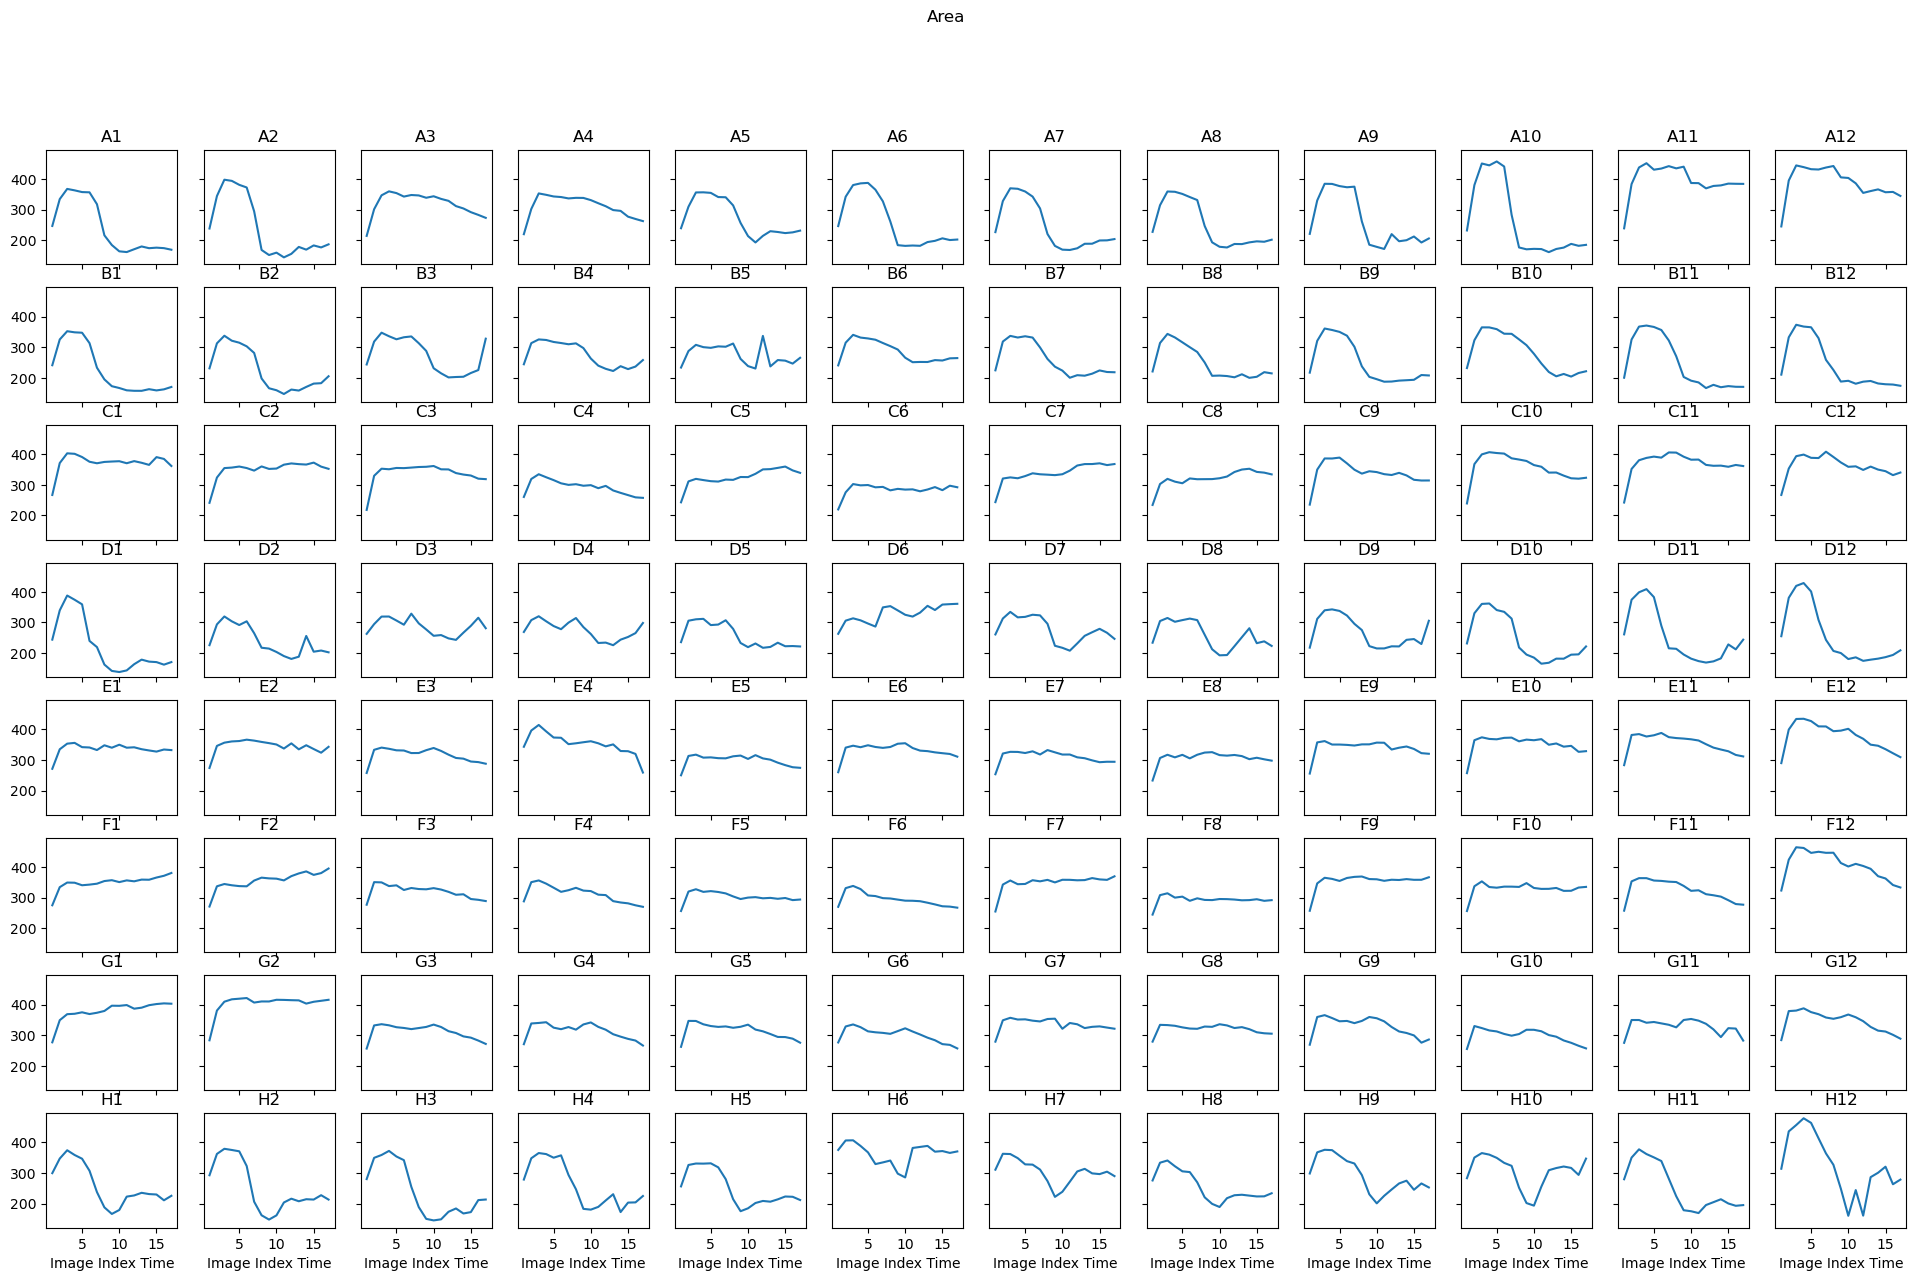

In [9]:
# Cell 7: Parameter Plotting
print('Plotting takes time. Please be patient whilst there is still an asterisk in the square bracket on the left, python is working on plotting the measurements.')
fig, axes = plt.subplots(nrows=8, ncols=12, sharex=True, sharey=True, figsize=(24, 14))
x = 0

for n in range(len(well_rows)):  # well rows
    for m in range(12):  # well columns
        well_name.append(well_rows[n] + str(m+1))
        #print(well_name[x])
        axes[n, m].set(title=well_name[x])
        try:
            print("Plotting data for well: ", well_name[x]) 
            live_pivot[well_name[x]].plot(x=x_axis_parameter, y=well_name[x], ax=axes[n, m], legend=None)
        except KeyError:
            print("No data available for well: ", well_name[x])        
        x = x + 1

fig.suptitle(parameter_name)

Plotting takes time. Please be patient whilst there is still an asterisk in the square bracket on the left, python is working on plotting the measurements.
Plotting data for well:  A1
Plotting data for well:  A2
Plotting data for well:  A3
Plotting data for well:  A4
Plotting data for well:  A5
Plotting data for well:  A6
Plotting data for well:  A7
Plotting data for well:  A8
Plotting data for well:  A9
Plotting data for well:  A10
Plotting data for well:  A11
Plotting data for well:  A12
Plotting data for well:  B1
Plotting data for well:  B2
Plotting data for well:  B3
Plotting data for well:  B4
Plotting data for well:  B5
Plotting data for well:  B6
Plotting data for well:  B7
Plotting data for well:  B8
Plotting data for well:  B9
Plotting data for well:  B10
Plotting data for well:  B11
Plotting data for well:  B12
Plotting data for well:  C1
Plotting data for well:  C2
Plotting data for well:  C3
Plotting data for well:  C4
Plotting data for well:  C5
Plotting data for well:  C

AttributeError: 'numpy.ndarray' object has no attribute 'set_ylim'

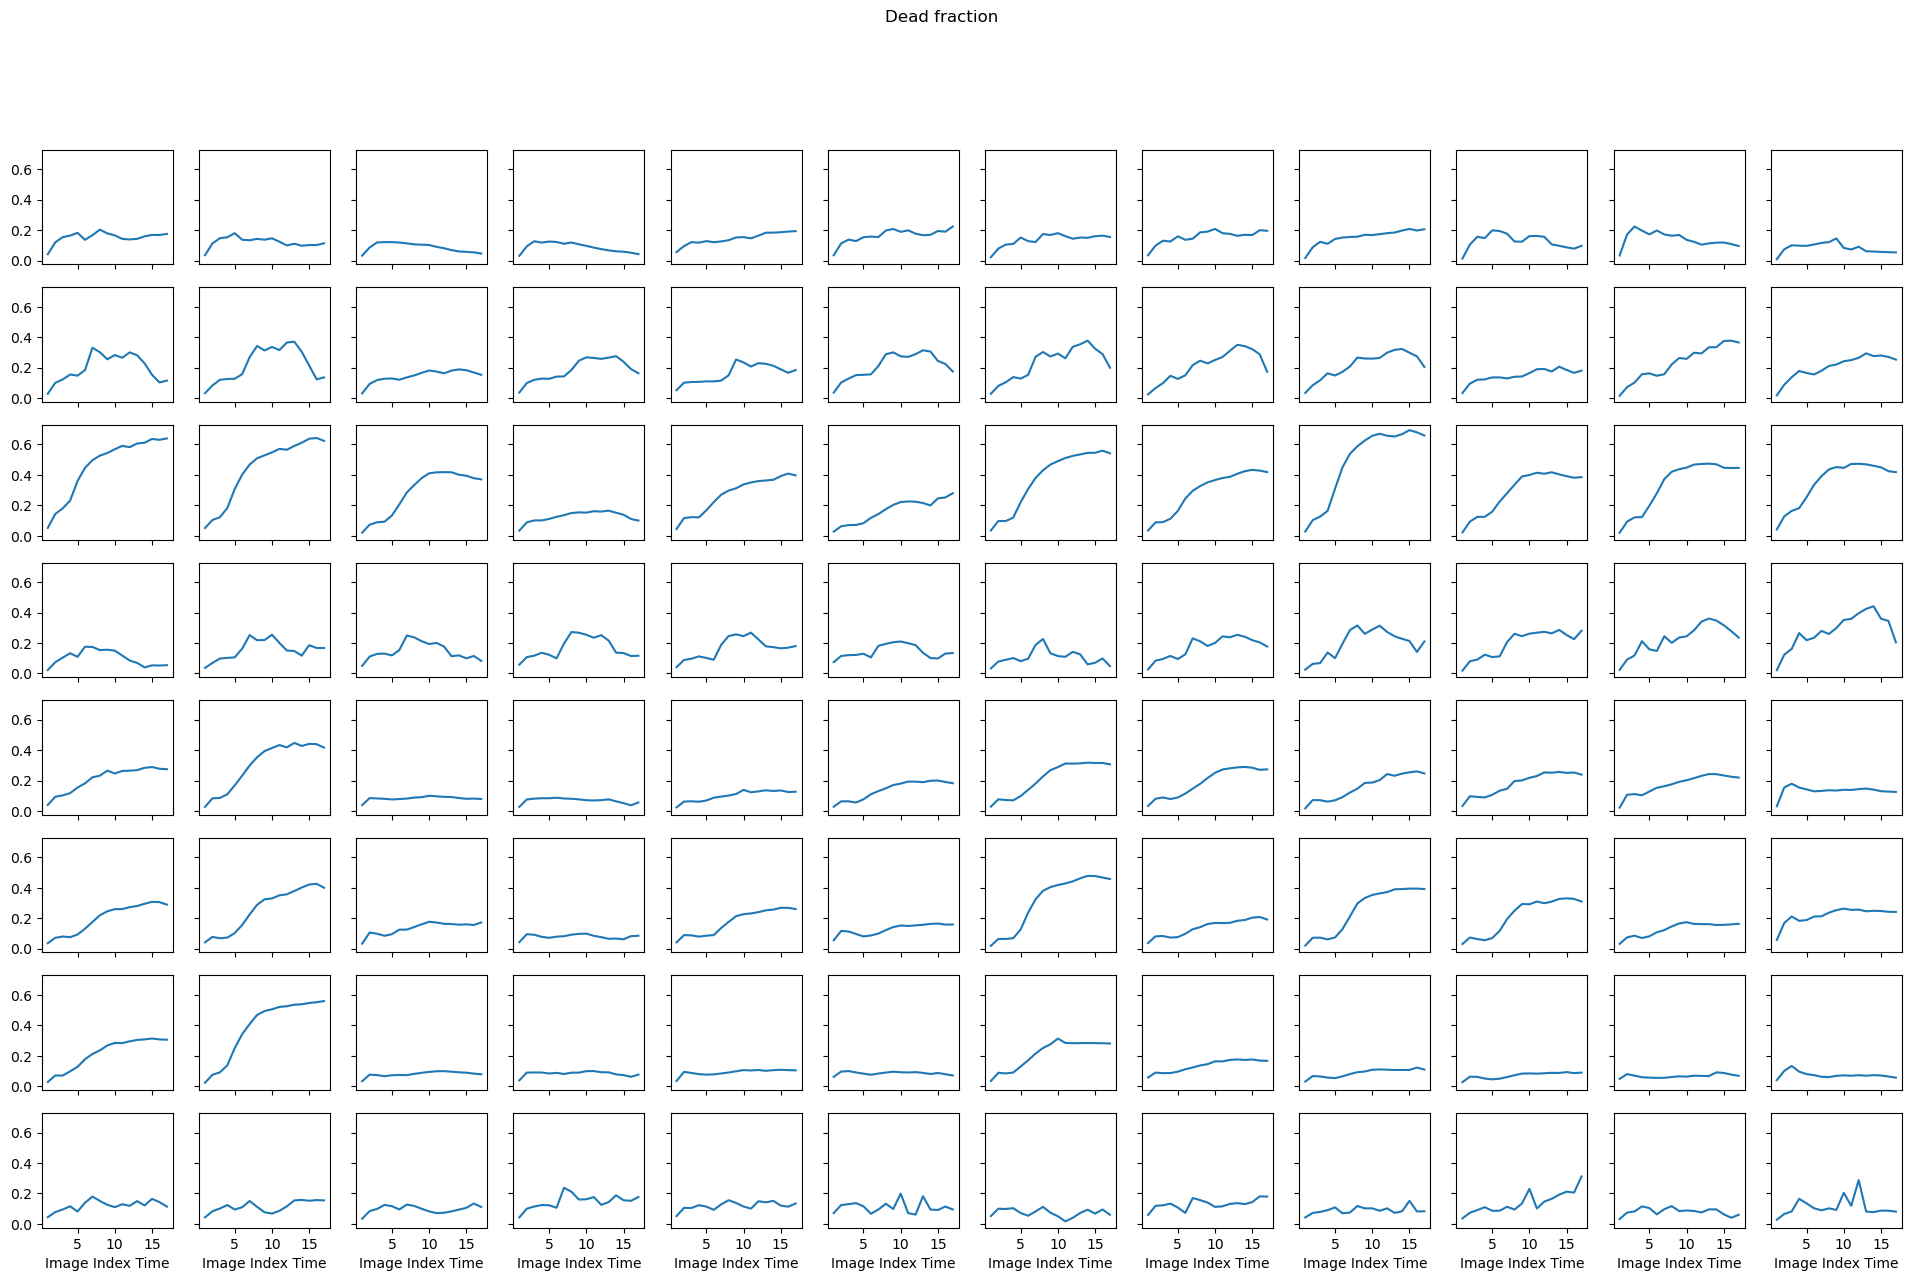

In [10]:
### Live/Dead Fraction Plotting
print('Plotting takes time. Please be patient whilst there is still an asterisk in the square bracket on the left, python is working on plotting the measurements.')
fig_fraction, axes_fraction = plt.subplots(nrows=8, ncols=12, sharex=True, sharey=True, figsize=(24, 14))
x = 0

for n in range(len(well_rows)):  # well rows
    for m in range(12):  # well columns
        well_name.append(well_rows[n] + str(m+1))
        #print(well_name[x])
        axes[n, m].set(title=well_name[x])
        try:
            print("Plotting data for well: ", well_name[x]) 
            dead_fraction[well_name[x]].plot(x=x_axis_parameter, y=well_name[x], ax=axes_fraction[n, m], legend=None)
        except KeyError:
            print("No data available for well: ", well_name[x])        
        x = x + 1

fig_fraction.suptitle("Dead fraction")
axes_fraction.set_ylim(0, 1)

In [11]:
# Cell 8: Save figures
fig.savefig(directory + "\\" +  filename + "_" + parameter_name + ".png")
fig_fraction.savefig(directory + "\\" +  filename + "_Dead-fraction.png")

print('Done! Deal with it any which way you like.')

plt.show()

Done! Deal with it any which way you like.
